[*********************100%***********************]  1 of 1 completed


Successfully downloaded 2011 days of stock data for AAPL!


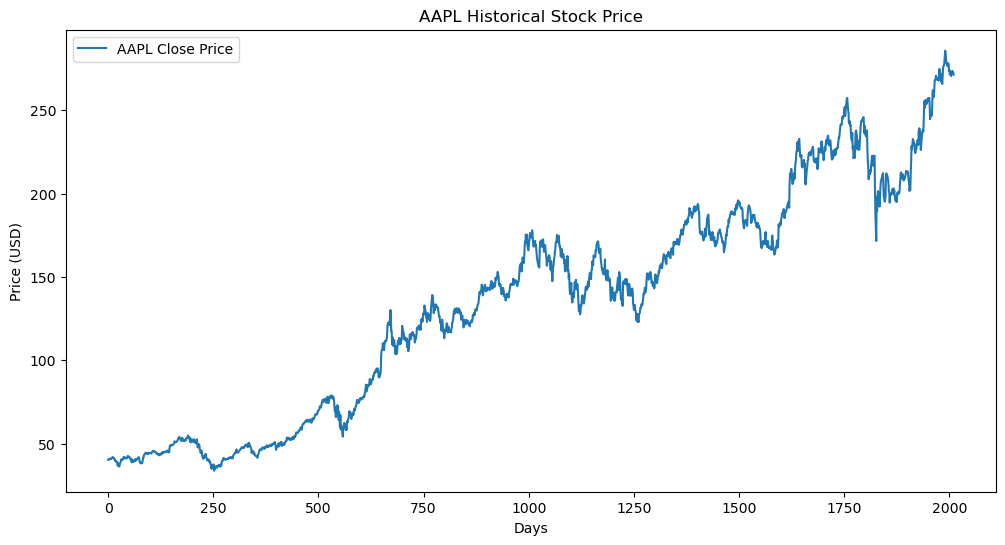

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# 1. Download historical data
ticker = 'AAPL'
data = yf.download(ticker, start='2018-01-01', end='2026-01-01')

# 2. Keep only the Close price
close_prices = data[['Close']].values

# 3. Scale features between 0 and 1 (Crucial for Neural Networks)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(close_prices)

print(f"Successfully downloaded {len(scaled_data)} days of stock data for {ticker}!")

# Quick plot to make sure it looks right
plt.figure(figsize=(12,6))
plt.plot(close_prices, label=f'{ticker} Close Price')
plt.title(f'{ticker} Historical Stock Price')
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

In [3]:
# Create empty lists to hold our features (X) and targets (y)
X = []
y = []

# Loop through the data starting from day 60
for i in range(60, len(scaled_data)):
    X.append(scaled_data[i-60:i, 0]) # Last 60 days
    y.append(scaled_data[i, 0])     # The 61st day (Target)

# Convert to numpy arrays
X, y = np.array(X), np.array(y)

# Reshape X to be 3D for PyTorch LSTM input: [samples, time_steps, features]
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

print(f"Features shape (X): {X.shape}")  # Should look like (Total_Days-60, 60, 1)
print(f"Targets shape (y): {y.shape}")   # Should look like (Total_Days-60,)

Features shape (X): (1951, 60, 1)
Targets shape (y): (1951,)


In [4]:
# Calculate the split index
split_index = int(len(X) * 0.80)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 1560
Testing samples: 391


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# 1. Convert NumPy arrays to PyTorch Tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1) # Reshape to (1560, 1)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# 2. Create a DataLoader to handle mini-batches during training
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False) # Keep order for time-series!

# 3. Define the LSTM Neural Network Model
class StockLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2, output_size=1):
        super(StockLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # The LSTM layer processing sequence data
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        
        # Fully connected layer to convert hidden states to a single price prediction
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        # Initialize hidden and cell states with zeros
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        # Forward pass through LSTM
        out, _ = self.lstm(x, (h0, c0))
        
        # Take the output of the very last time step (day 60) to predict day 61
        out = self.fc(out[:, -1, :])
        return out

# 4. Instantiate the model, loss function, and optimizer
model = StockLSTM()
criterion = nn.MSELoss() # Mean Squared Error is standard for regression tasks
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)

StockLSTM(
  (lstm): LSTM(1, 50, num_layers=2, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)


In [7]:
epochs = 10
print("Starting training...")

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()         # Clear past calculations
        predictions = model(batch_X)   # Make predictions for these 32 windows
        loss = criterion(predictions, batch_y) # Calculate error
        loss.backward()               # Backpropagation (learn from mistakes)
        optimizer.step()              # Tweak the neural network weights
        
        epoch_loss += loss.item()
        
    print(f"Epoch {epoch+1}/{epochs} | Average Loss: {epoch_loss/len(train_loader):.6f}")

print("Training finished successfully!")

Starting training...
Epoch 1/10 | Average Loss: 0.013316
Epoch 2/10 | Average Loss: 0.068889
Epoch 3/10 | Average Loss: 0.041777
Epoch 4/10 | Average Loss: 0.025538
Epoch 5/10 | Average Loss: 0.006297
Epoch 6/10 | Average Loss: 0.000604
Epoch 7/10 | Average Loss: 0.000798
Epoch 8/10 | Average Loss: 0.000404
Epoch 9/10 | Average Loss: 0.000595
Epoch 10/10 | Average Loss: 0.000473
Training finished successfully!


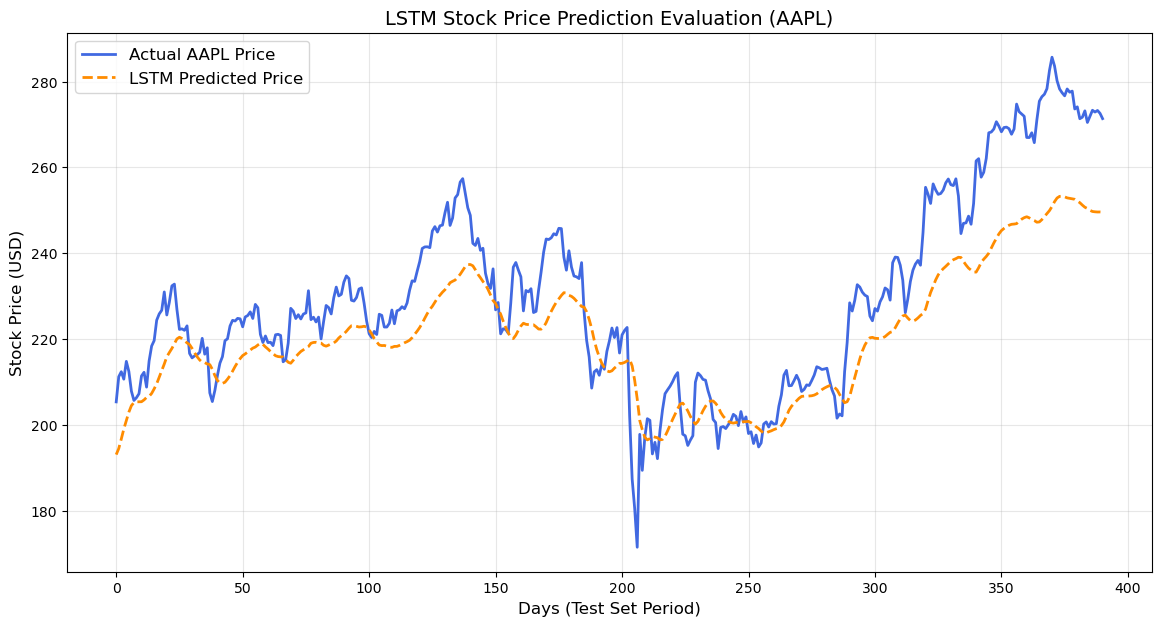

In [8]:
# 1. Switch model to evaluation mode
model.eval()

# 2. Make predictions on the test data without calculating gradients
with torch.no_grad():
    test_predictions = model(X_test_t).numpy()

# 3. Inverse transform the data back into actual USD prices
# (Right now the data is between 0 and 1, we need actual dollar values)
test_predictions_real = scaler.inverse_transform(test_predictions)

# We also need to un-scale the actual true values to compare them fairly
y_test_real = scaler.inverse_transform(y_test_t.numpy())

# 4. Plot the results!
plt.figure(figsize=(14, 7))
plt.plot(y_test_real, label="Actual AAPL Price", color='royalblue', linewidth=2)
plt.plot(test_predictions_real, label="LSTM Predicted Price", color='darkorange', linestyle='--', linewidth=2)

plt.title("LSTM Stock Price Prediction Evaluation (AAPL)", fontsize=14)
plt.xlabel("Days (Test Set Period)", fontsize=12)
plt.ylabel("Stock Price (USD)", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
from sklearn.metrics import mean_squared_error

# 1. Calculate RMSE (tells us on average how many dollars out the predictions are)
rmse = np.sqrt(mean_squared_error(y_test_real, test_predictions_real))
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")

# 2. Calculate Directional Accuracy (Did it correctly predict if the price would go UP or DOWN?)
actual_delta = np.diff(y_test_real.flatten()) > 0
pred_delta = np.diff(test_predictions_real.flatten()) > 0
directional_acc = np.mean(actual_delta == pred_delta) * 100
print(f"Directional Accuracy: {directional_acc:.2f}%")

Root Mean Squared Error (RMSE): $13.12
Directional Accuracy: 50.77%


In [10]:
# 1. Instantiate the network with a larger hidden size
model = StockLSTM(hidden_size=128)

# 2. Define loss function
criterion = nn.MSELoss()

# 3. Setup optimizer with a smaller, more careful learning rate
optimizer = optim.Adam(model.parameters(), lr=0.0005)

print("Optimized model configuration ready!")
print(model)

Optimized model configuration ready!
StockLSTM(
  (lstm): LSTM(1, 128, num_layers=2, batch_first=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


In [11]:
epochs = 30
print("Starting optimized training loop...")

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()         
        predictions = model(batch_X)   
        loss = criterion(predictions, batch_y) 
        loss.backward()               
        optimizer.step()              
        
        epoch_loss += loss.item()
        
    # Print progress every 5 epochs so the notebook stays clean
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{epochs} | Average Loss: {epoch_loss/len(train_loader):.6f}")

print("Optimized training finished successfully!")

Starting optimized training loop...
Epoch 1/30 | Average Loss: 0.006537
Epoch 5/30 | Average Loss: 0.032444
Epoch 10/30 | Average Loss: 0.001180
Epoch 15/30 | Average Loss: 0.000273
Epoch 20/30 | Average Loss: 0.000275
Epoch 25/30 | Average Loss: 0.000299
Epoch 30/30 | Average Loss: 0.000443
Optimized training finished successfully!


In [12]:
from sklearn.metrics import mean_squared_error

# 1. Recalculate RMSE
test_predictions = model(X_test_t).detach().numpy()
test_predictions_real = scaler.inverse_transform(test_predictions)
y_test_real = scaler.inverse_transform(y_test_t.numpy())

rmse = np.sqrt(mean_squared_error(y_test_real, test_predictions_real))
print(f"New Root Mean Squared Error (RMSE): ${rmse:.2f}")

# 2. Recalculate Directional Accuracy
actual_delta = np.diff(y_test_real.flatten()) > 0
pred_delta = np.diff(test_predictions_real.flatten()) > 0
directional_acc = np.mean(actual_delta == pred_delta) * 100
print(f"New Directional Accuracy: {directional_acc:.2f}%")

New Root Mean Squared Error (RMSE): $11.57
New Directional Accuracy: 51.54%


In [13]:
# 1. Grab the absolute last 60 days of data from our scaled dataset
last_60_days_scaled = scaled_data[-60:]

# 2. Reshape it to match the PyTorch LSTM input shape: [1 sample, 60 time steps, 1 feature]
last_60_days_scaled = np.reshape(last_60_days_scaled, (1, 60, 1))

# 3. Convert to a PyTorch Tensor
last_60_days_tensor = torch.tensor(last_60_days_scaled, dtype=torch.float32)

# 4. Put model in evaluation mode and predict
model.eval()
with torch.no_grad():
    tomorrow_prediction_scaled = model(last_60_days_tensor).numpy()

# 5. Inverse scale the prediction to see the actual dollar amount
tomorrow_prediction_real = scaler.inverse_transform(tomorrow_prediction_scaled)

print("==================================================")
print(f"🔮 Predicted AAPL Close Price for the next trading day: ${tomorrow_prediction_real[0][0]:.2f}")
print("==================================================")

🔮 Predicted AAPL Close Price for the next trading day: $253.30


In [15]:
# Save the model state dictionary
torch.save(model.state_dict(), 'lstm_stock_model.pth')
print("Model weights successfully saved to 'lstm_stock_model.pth'!")

Model weights successfully saved to 'lstm_stock_model.pth'!


In [16]:
# 1. Create a brand new, untrained instance of your model architecture
loaded_model = StockLSTM(hidden_size=128)

# 2. Load the saved weights from your hard drive into this new model
loaded_model.load_state_dict(torch.load('lstm_stock_model.pth'))

# 3. Set it to evaluation mode
loaded_model.eval()

print("Model weights loaded successfully! This model is ready to predict instantly without training.")

Model weights loaded successfully! This model is ready to predict instantly without training.
